In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm
import cv2
import tifffile
from skimage.transform import resize
from dotenv import load_dotenv

from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Flatten, Conv2D, Reshape, Input, Conv2DTranspose
from keras.layers import Activation, LeakyReLU, BatchNormalization, Dropout
# # import dcgan as dcgan
# # import wgan as wgan
# # import prgan as prgan
# import importlib
import ppgan3 as ppgan3
import torch

from scores import scores
from scores import preprocess_array
import os

from tensorflow.keras.optimizers import Adam


/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# Load the environment variables from the .env file
load_dotenv()

# Access the environment variables using os.getenv()
MAIN_DIR = os.getenv('MAIN_DIR')
SYNTHETIC_PATH = os.getenv('SYNTHETIC_PATH')
NOISE_DIM = int(os.getenv('NOISE_DIM'))
BATCH_SIZE = int(os.getenv('BATCH_SIZE'))
EPOCHS = int(os.getenv('EPOCHS'))
STEPS = int(os.getenv('STEPS'))
SEED = int(os.getenv('SEED'))
WIDTH, HEIGHT, CHANNELS = int(os.getenv('WIDTH')), int(os.getenv('HEIGHT')), int(os.getenv('CHANNELS'))

#OPTIMIZER = tf.keras.optimizers.legacy.Adam(0.0002, 0.5) #M1 Optimizer
OPTIMIZER = Adam(float(os.getenv('LR')), float(os.getenv('BETA_1')))

In [11]:

MAIN_DIR = MAIN_DIR+'/10-26'
def load_images(folder):
    imgs = []
    target = 1
    labels = []
    for i in os.listdir(folder):
        if i.endswith("_UNHEALTHY.tif"):
            img_dir = os.path.join(folder,i)
            try:
                img = tifffile.imread(img_dir)

                img = img[:,:,:]
                
                img = cv2.resize(img, (128,128))
                import sys
                import numpy
                numpy.set_printoptions(threshold=sys.maxsize)
                img = (img / 256).astype(np.uint8)                
                imgs.append(img)
                labels.append(target)
            except:
                continue
                
    imgs = np.array(imgs)
    labels = np.array(labels)

    return imgs, labels

In [12]:
data, labels = load_images(MAIN_DIR)
print(len(data))

26


In [13]:
np.random.seed(SEED)
idxs = np.random.randint(0, data.shape[0], BATCH_SIZE)
X_train = data
print(len(X_train))

26


0


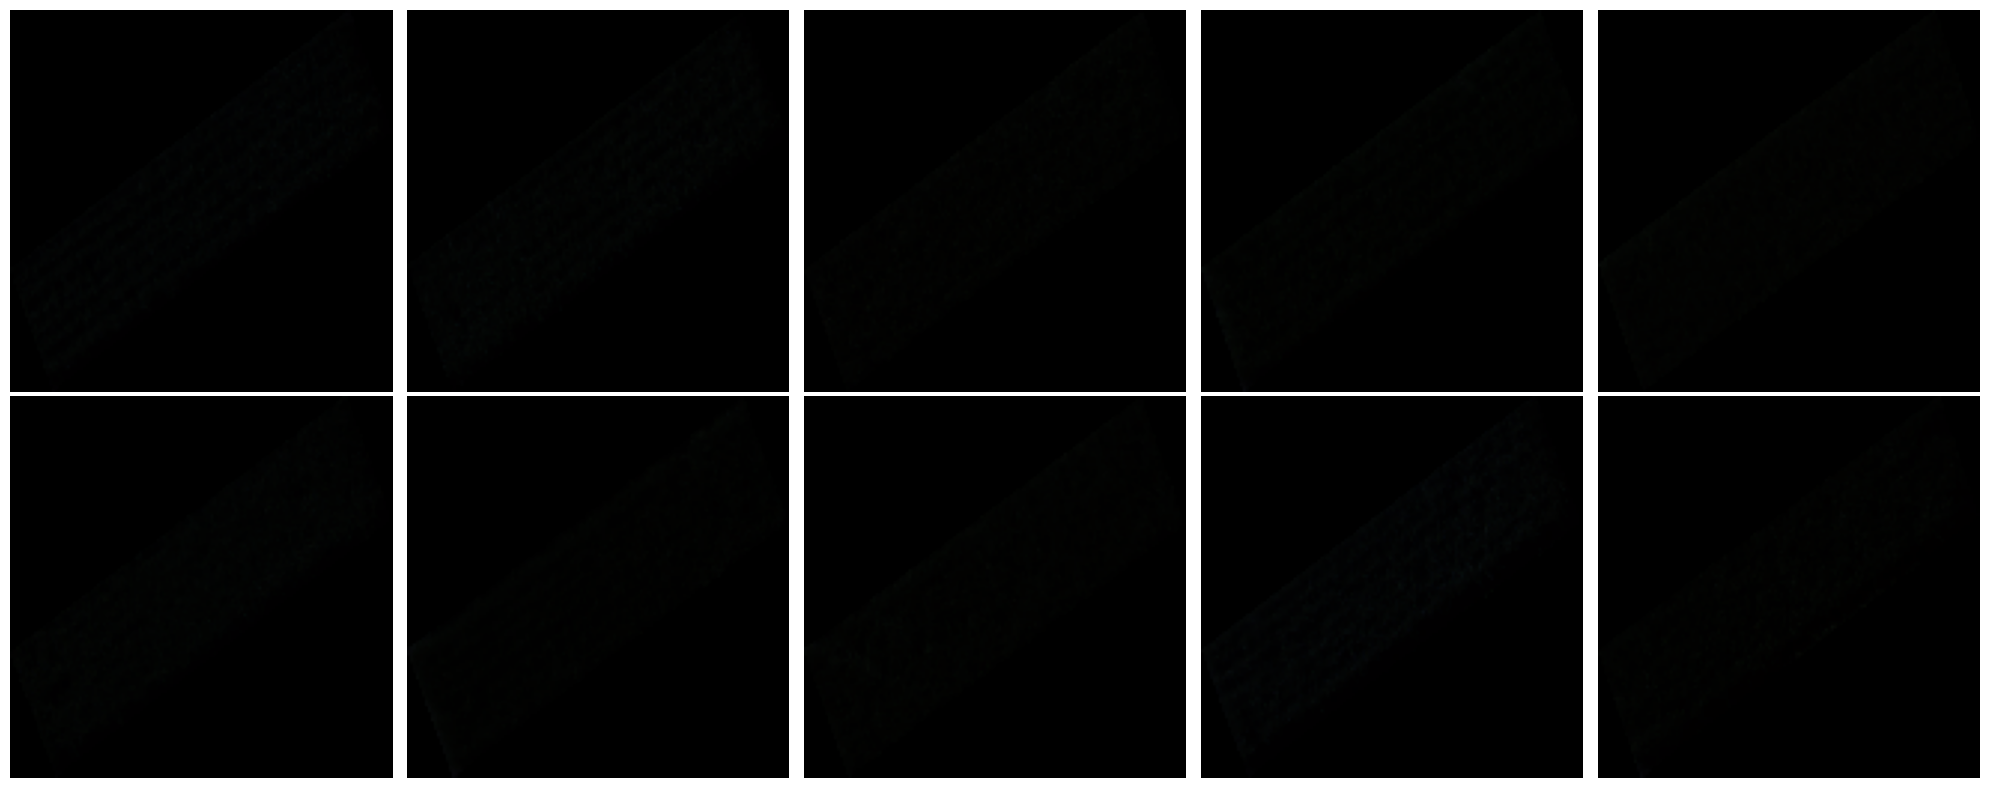

In [14]:

plt.figure(figsize=(20,8))
for i in range(10):
    axs = plt.subplot(2,5,i+1)
    plt.imshow(X_train[i][:,:,:3], vmin=-1, vmax=1)
    plt.axis('off')
    axs.set_xticklabels([])
    axs.set_yticklabels([])
    plt.subplots_adjust(wspace=None, hspace=None)
plt.tight_layout()
X_train.shape
print(np.amin(X_train))

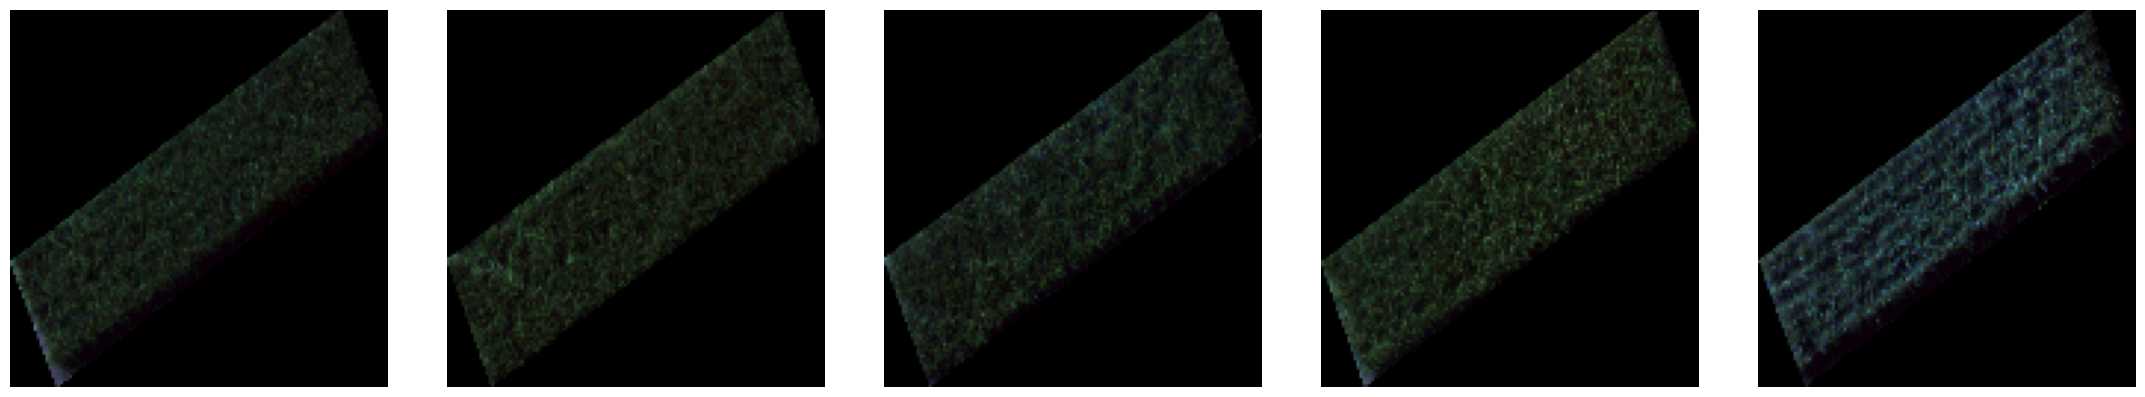

In [20]:
# Normalize the Images
X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min())

# Reshape images 
X_train = X_train.reshape(-1, WIDTH,HEIGHT,CHANNELS)

# Check shape
X_train.shape

plt.figure(figsize=(22,8))
for i in range(5):
    axs = plt.subplot(2,5,i+1)
    plt.imshow(X_train[i][:,:,:3], vmin=-1, vmax=1)
    plt.axis('off')
    axs.set_xticklabels([])
    axs.set_yticklabels([])
    plt.subplots_adjust(wspace=None, hspace=None)
plt.tight_layout()

In [25]:
import importlib 
importlib.reload(ppgan3)
# importlib.reload(dcgan)
# importlib.reload(wgan)
noise = np.random.normal(0,1, size=(BATCH_SIZE, NOISE_DIM))
# noise_wgan = tf.random.normal([BATCH_SIZE, NOISE_DIM])

In [26]:
from keras.models import load_model
import warnings

# Suppress the warning
#warnings.filterwarnings("ignore", message="You are casting an input of type complex64 to an incompatible dtype float32.")
#tf.get_logger().setLevel('ERROR')

# # print('DCGAN TRAINING STARTED...')
# # generator_dcgan, discriminator_dcgan, dcgan_model = dcgan.build(OPTIMIZER, NOISE_DIM, WIDTH, HEIGHT, CHANNELS)
# # generator_dcgan, generator_dcgan_loss_values = dcgan.train(X_train, generator_dcgan, discriminator_dcgan, dcgan_model, noise, EPOCHS, STEPS, BATCH_SIZE, NOISE_DIM)
print('PPGAN TRAINING STARTED...')
generator1_ppgan, generator2_ppgan, discriminator_ppgan1, discriminator_ppgan2, discriminator_ppgan3, ppgan_model = ppgan3.build(Adam(0.0002, 0.5), NOISE_DIM, WIDTH, HEIGHT, CHANNELS)
generator1_ppgan, generator1_ppgan_loss_values, generator2_ppgan, generator2_ppgan_loss_values = ppgan3.train(X_train, generator1_ppgan, generator2_ppgan, discriminator_ppgan1, discriminator_ppgan2, discriminator_ppgan3, ppgan_model, EPOCHS, STEPS, BATCH_SIZE, NOISE_DIM)
# # print('WGAN TRAINING STARTED...')
# # generator_wgan, generator_wgan_loss_values = wgan.train(X_train, WIDTH, HEIGHT, CHANNELS, NOISE_DIM, Adam(0.0002, 0.5), EPOCHS, STEPS, BATCH_SIZE)

import pickle
# # #Save the generator and losses
# # with open('trained_dcgan_loss.pkl', 'wb') as file:
# #     data = {
# #         'losses': generator_dcgan_loss_values
# #     }
# #     pickle.dump(data, file)
# # generator_dcgan.save('trained_dcgan.h5')

with open('trained_ppgan3_loss_50_1026.pkl', 'wb') as file:
    data = {
        'losses': generator1_ppgan_loss_values
    }
    pickle.dump(data, file)
generator1_ppgan.save('trained_ppgan3_50_1026_PREVIOUS_QUAC.h5')
generator2_ppgan.save('trained_ppgan3_50_1026_PREVIOUS_QUAC-2.h5')

# # with open('trained_wgan_loss_.pkl', 'wb') as file:
# #     data = {
# #         'losses': generator_wgan_loss_values
# #     }
# #     pickle.dump(data, file)
# # generator_wgan.save('trained_wgan.h5')

'EPOCH: 50 Generator 1 Loss: 2.1591 Generator 2 Loss: 0.9290 Discriminator 1 Loss: 0.4894 Discriminator 2 Loss: 20.0777 Discriminator 3 Loss: 13.6295'

C:\Users\flopes1\AppData\Roaming\Python\Python39\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
args_dict = {
    'latent_dim': 128,
    'image_size': 128,
    'num_codebook_vectors': 256,
    'beta': 0.25,
    'image_channels': 3,
    'dataset_path': '/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/08-30',
    'device': 'mps',
    'batch_size': 6,
    'epochs': 50,
    'learning_rate': 2.25e-05,
    'beta1': 0.5,
    'beta2': 0.9,
    'disc_start': 10000,
    'disc_factor': 1.0,
    'rec_loss_factor': 1.0,
    'perceptual_loss_factor': 1.0
}

class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

# Create an instance of the AttrDict class using your args_dict
args = AttrDict(args_dict)

In [49]:
from keras.models import load_model

import pickle

from VQGAN.vqgan import VQGAN
# Load the saved data
############################################### 08-30-2021 ###############################################
# # Access the loaded data
#with open('trained_dcgan_loss_0830.pkl', 'rb') as file2:
#    loaded_data = pickle.load(file2)
#generator_dcgan_0830 = load_model('trained_dcgan_0830_QUAC.h5')
#dcgan_losses_0830 = loaded_data['losses']

with open('trained_ppgan3_loss_50_1026.pkl', 'rb') as file2:
    loaded_data = pickle.load(file2)
# # # Access the loaded data
ppgan3_losses_1007 = loaded_data['losses']
generator1_ppgan3 = load_model('trained_ppgan3_50_1026_PREVIOUS_QUAC.h5')
generator2_ppgan3 = load_model('trained_ppgan3_50_1026_PREVIOUS_QUAC-2.h5')

# with open('trained_wgan_loss_0830.pkl', 'rb') as file3:
#     loaded_data = pickle.load(file3)
# # # # Access the loaded data
# wgan_losses_0830 = loaded_data['losses']
# generator_wgan_0830 = load_model('trained_wgan_0830_QUAC.h5')

# generator_vqgan_0830 = VQGAN(args)
# checkpoint = torch.load(r"/Users/felipealencar/Desktop/plant-disease-prediction/VQGAN/checkpoints/vqgan_epoch_49.pt")
# generator_vqgan_0830.load_state_dict(checkpoint)
############################################### 08-30-2021 ###############################################

############################################### 09-24-2021 ###############################################
# # Access the loaded data
# with open('trained_dcgan_loss_0924.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# generator_dcgan_0924 = load_model('trained_dcgan_0924_QUAC.h5')
# dcgan_losses_0924 = loaded_data['losses']

# with open('trained_ppgan_loss_0924.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# # # Access the loaded data
# ppgan_losses_0924 = loaded_data['losses']
# generator_ppgan_0924 = load_model('trained_ppgan_0924_QUAC.h5')

# with open('trained_wgan_loss_0924.pkl', 'rb') as file3:
#     loaded_data = pickle.load(file3)
# # # Access the loaded data
# wgan_losses_0924 = loaded_data['losses']
# generator_wgan_0924 = load_model('trained_wgan_0924_QUAC.h5')
############################################### 09-24-2021 ###############################################

############################################### 10-05-2021 ###############################################
# Access the loaded data
# with open('trained_dcgan_loss_1005.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# generator_dcgan_1005 = load_model('trained_dcgan_1005_QUAC.h5')
# dcgan_losses_1005 = loaded_data['losses']

# with open('trained_ppgan_loss_1005.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# # # Access the loaded data
# ppgan_losses_1005 = loaded_data['losses']
# generator_ppgan_1005 = load_model('trained_ppgan_1005_QUAC.h5')

# with open('trained_wgan_loss_1005.pkl', 'rb') as file3:
#     loaded_data = pickle.load(file3)
# # # Access the loaded data
# wgan_losses_1005 = loaded_data['losses']
# generator_wgan_1005 = load_model('trained_wgan_1005_QUAC.h5')
############################################### 10-05-2021 ###############################################

############################################### 10-07-2021 ###############################################
# # Access the loaded data
# with open('trained_dcgan_loss_1026.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# generator_dcgan_1026 = load_model('trained_dcgan_1026_QUAC.h5')
# dcgan_losses_1026 = loaded_data['losses']

# with open('trained_ppgan_loss_1007.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# # # Access the loaded data
# ppgan_losses_1007 = loaded_data['losses']
# generator_ppgan_1007 = load_model('trained_ppgan_1007_QUAC.h5')

# with open('trained_wgan_loss_1026.pkl', 'rb') as file3:
#     loaded_data = pickle.load(file3)
# # # Access the loaded data
# wgan_losses_1026 = loaded_data['losses']
# generator_wgan_1026 = load_model('trained_wgan_1026_QUAC.h5')
############################################### 10-07-2021 ###############################################

############################################### 10-26-2021 ###############################################
# # Access the loaded data
# with open('trained_dcgan_loss_1026.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# generator_dcgan_1026 = load_model('trained_dcgan_1026_QUAC.h5')
# dcgan_losses_1026 = loaded_data['losses']

# with open('trained_ppgan_loss_1026.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# # # Access the loaded data
# ppgan_losses_1026 = loaded_data['losses']
# generator_ppgan_1026 = load_model('trained_ppgan_1026_QUAC.h5')

# with open('trained_wgan_loss_1026.pkl', 'rb') as file3:
#     loaded_data = pickle.load(file3)
# # # Access the loaded data
# wgan_losses_1026 = loaded_data['losses']
# generator_wgan_1026 = load_model('trained_wgan_1026_QUAC.h5')
############################################### 10-26-2021 ###############################################

In [ ]:
%pip install pydot

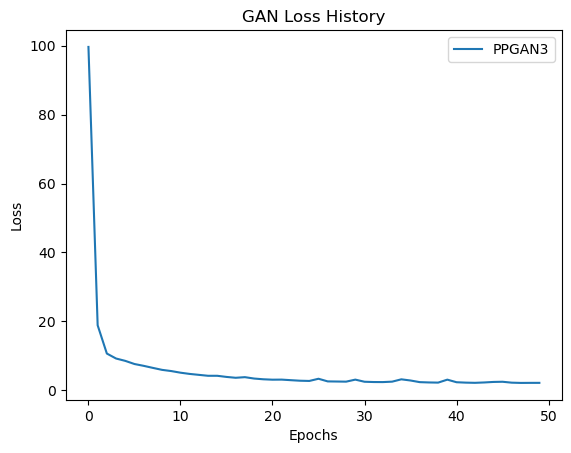

In [50]:
import pickle
import matplotlib.pyplot as plt

# Load loss history from DCGAN
#with open('trained_dcgan_loss_0830.pkl', 'rb') as f:
#    dcgan_loss = pickle.load(f)

# Load loss history from PPGAN
with open('trained_ppgan3_loss_50_1026.pkl', 'rb') as f:
    ppgan_loss = pickle.load(f)

# Load loss history from WGAN
#with open('trained_wgan_loss_0830.pkl', 'rb') as f:
#    wgan_loss = pickle.load(f)

# Plot loss history for all models
#plt.plot(dcgan_loss['losses'], label='DCGAN')
plt.plot(ppgan_loss['losses'], label='PPGAN3')
#plt.plot(wgan_loss['losses'], label='WGAN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('GAN Loss History')
plt.legend()
plt.show()


1/1 [==============================] - 0s 383ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(5, 128, 128)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(5, 128, 128)
(5, 128, 128)
(5, 128, 128)
(5, 128, 128)


...

(5, 128, 128)
(5, 128, 128)
(5, 128, 128)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(5, 128, 128)
(5, 128, 128)
(5, 128, 128)
(5, 128, 128)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(5, 128, 128)


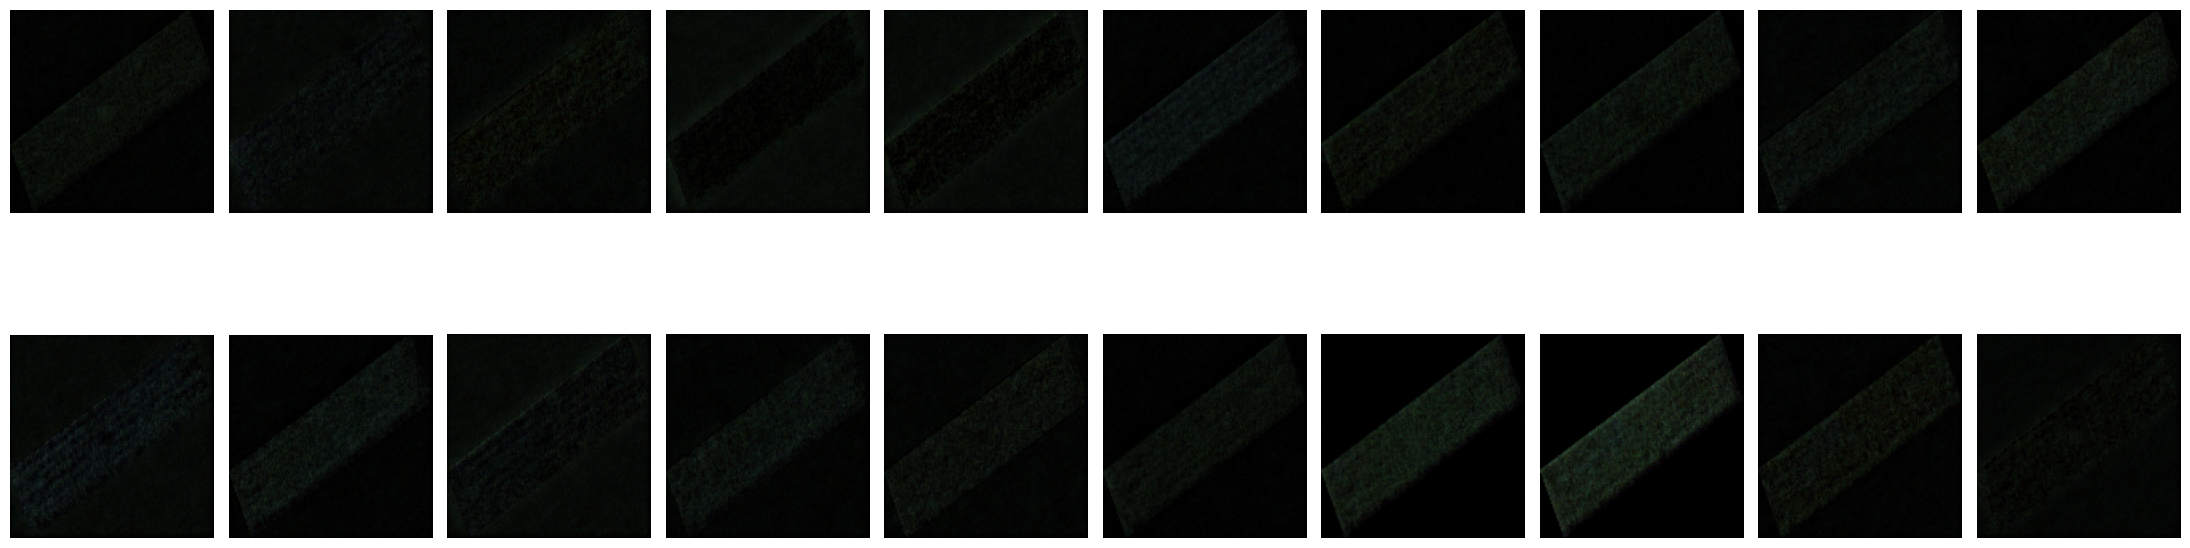

1/1 [==============================] - 0s 461ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(5, 128, 128)
(5, 128, 128)
(5, 128, 128)
(5, 128, 128)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(5, 128, 128)
(5, 128, 128)
(5, 128, 128)
(5, 128, 128)


...

(5, 128, 128)
(5, 128, 128)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(5, 128, 128)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(5, 128, 128)
(5, 128, 128)
(5, 128, 128)


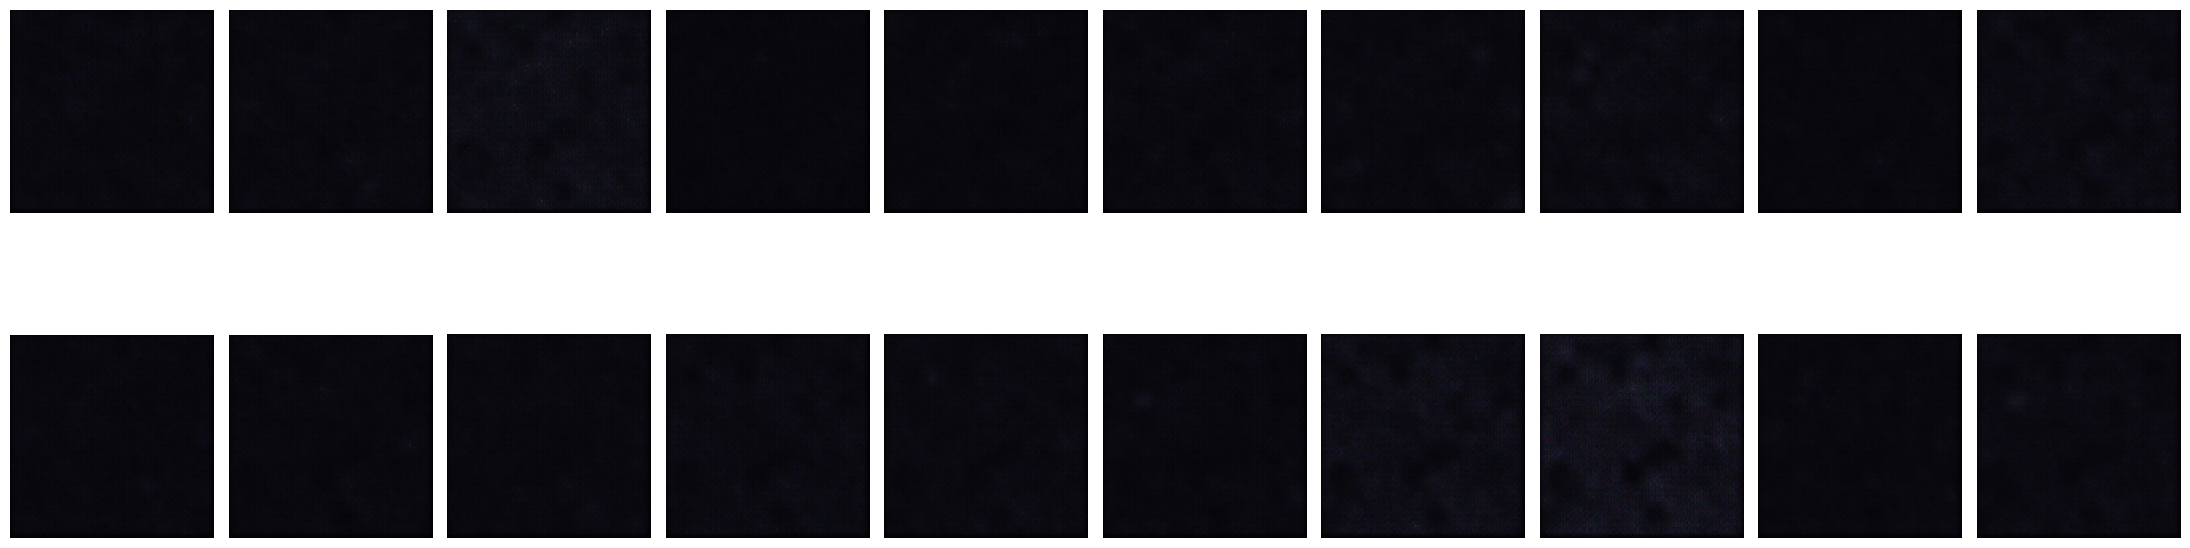

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


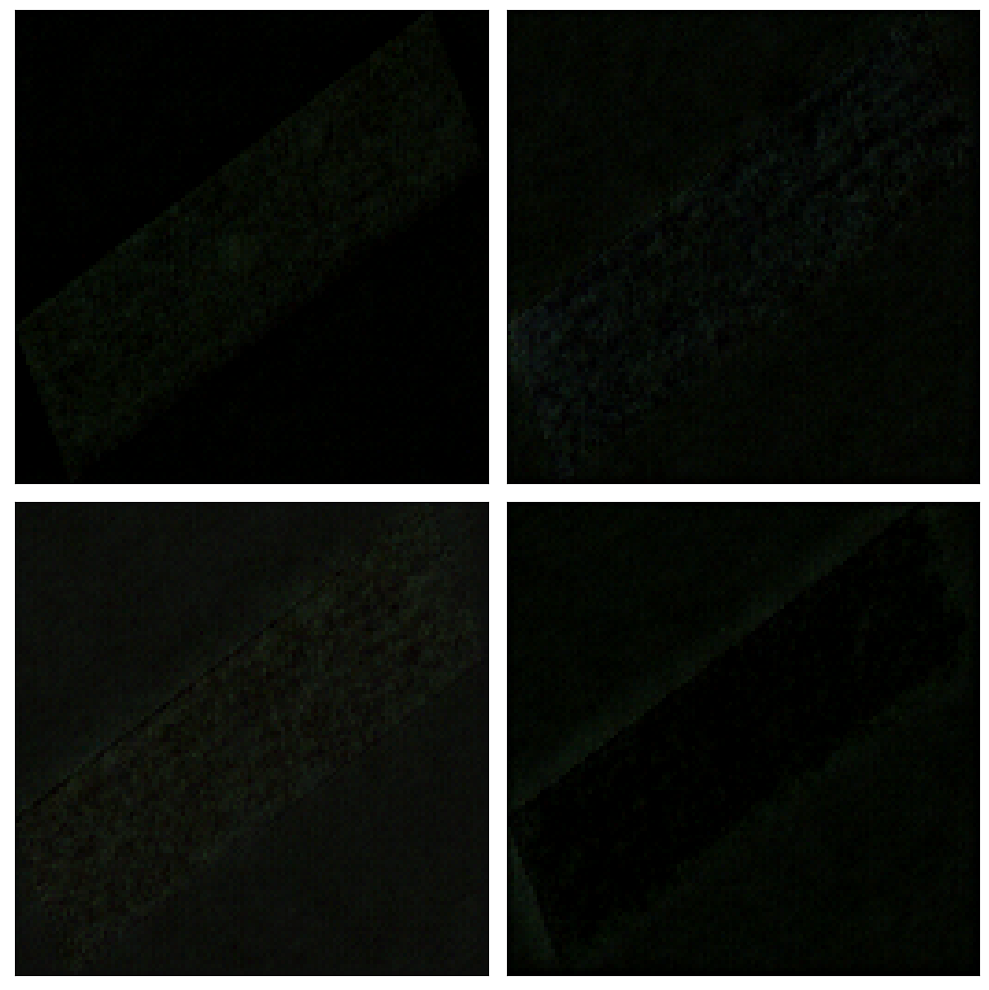

In [51]:
import matplotlib.pyplot as plt
import utils
importlib.reload(utils)
noise = np.random.normal(0, 1, size=(BATCH_SIZE, NOISE_DIM))
samples1_ppgan3 = utils.sample_images(generator1_ppgan3, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1026-50-PREVIOUSDATE', model='PPGAN_HEALTHY', path=SYNTHETIC_PATH, save=True)
samples2_ppgan3 = utils.sample_images(generator2_ppgan3, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1026-50-PREVIOUSDATE-2', model='PPGAN_HEALTHY', path=SYNTHETIC_PATH, save=True)
result = [
    ((x - (y/7))/2 if (x != 0).all else 0)
    for x, y in zip(samples1_ppgan3, samples2_ppgan3)
]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))  # Create a 2x2 grid

for i, ax in enumerate(axes.flat):
    if i < 4:  # Display only the first four images
        ax.imshow(result[i][:,:,:3], vmin=-1, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()
#samples_dcgan_0830 = utils.sample_images(generator_dcgan_0830, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='0830', model='DCGAN', path=SYNTHETIC_PATH, save=False)
#samples_wgan_0830 = utils.sample_images(generator_wgan_0830, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='0830', model='WGAN', path=SYNTHETIC_PATH, save=False)

#from VQGAN.utils import load_data, weights_init
#train_dataset = load_data(args)
#for imgs in train_dataset:
#    imgs = imgs.to(device=args.device)
#    decoded_images, _, q_loss = generator_vqgan_0830(imgs)
#samples_vqgan_0830 = torch.cat((imgs[:5], decoded_images.add(1).mul(0.5)[:4]))
# samples_ppgan_0924 = utils.sample_images(generator_ppgan_0924, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='0924', model='PPGAN_HEALTHY', path=SYNTHETIC_PATH, save=True)
# # samples_dcgan_0924 = utils.sample_images(generator_dcgan_0924, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='0924', model='DCGAN', path=SYNTHETIC_PATH, save=True)
# # samples_wgan_0924 = utils.sample_images(generator_wgan_0924, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='0924', model='WGAN', path=SYNTHETIC_PATH, save=True)
# samples_ppgan_1005 = utils.sample_images(generator_ppgan_1005, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1005', model='PPGAN_HEALTHY', path=SYNTHETIC_PATH, save=True)
#  samples_ppgan_1007 = utils.sample_images(generator_ppgan_1007, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1007', model='UNHEALTHY', path=SYNTHETIC_PATH, save=True)
# # samples_dcgan_1005 = utils.sample_images(generator_dcgan_1005, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1005', model='DCGAN', path=SYNTHETIC_PATH, save=True)
# # samples_wgan_1005 = utils.sample_images(generator_wgan_1005, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1005', model='WGAN', path=SYNTHETIC_PATH, save=True)
# samples_ppgan_1026 = utils.sample_images(generator_ppgan_1026, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1026', model='PPGAN_HEALTHY', path=SYNTHETIC_PATH, save=True)
# # samples_dcgan_1026 = utils.sample_images(generator_dcgan_1026, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1026', model='DCGAN', path=SYNTHETIC_PATH, save=True)
# # samples_wgan_1026 = utils.sample_images(generator_wgan_1026, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1026', model='WGAN', path=SYNTHETIC_PATH, save=True)

In [ ]:
import scores
importlib.reload(scores) 
from scores import scores, preprocess_array

X_train_array = np.array(X_train)
X_train_array = preprocess_array(X_train_array)

samples_dcgan_array_0830 = np.array(samples_dcgan_0830)
samples_ppgan_array_0830 = np.array(samples_ppgan_0830)
samples_wgan_array_0830 = np.array(samples_wgan_0830)

samples_vqgan_0830_cpu = samples_vqgan_0830.cpu()
samples_vqgan_array_0830 = np.array(samples_vqgan_0830_cpu.detach().numpy())
# samples_dcgan_array_0924 = np.array(samples_dcgan_0924)
# samples_ppgan_array_0924 = np.array(samples_ppgan_0924)
# samples_wgan_array_0924 = np.array(samples_wgan_0924)
# samples_dcgan_array_1005 = np.array(samples_dcgan_1005)
# samples_ppgan_array_1005 = np.array(samples_ppgan_1005)
# samples_wgan_array_1005 = np.array(samples_wgan_1005)
# samples_dcgan_array_1026 = np.array(samples_dcgan_1026)
# samples_ppgan_array_1026 = np.array(samples_ppgan_1026)
# samples_wgan_array_1026 = np.array(samples_wgan_1026)

samples_dcgan_array_0830 = preprocess_array(samples_dcgan_array_0830)
samples_dcgan_array_0830[:, :, :, 3:] = samples_dcgan_array_0830[:, :, :, 3:] * 1.3
samples_ppgan_array_0830 = preprocess_array(samples_ppgan_array_0830)
samples_ppgan_array_0830[:, :, :, 3:] = samples_ppgan_array_0830[:, :, :, 3:] * 1.3
samples_wgan_array_0830 = preprocess_array(samples_wgan_array_0830)
samples_wgan_array_0830[:, :, :, 3:] = samples_wgan_array_0830[:, :, :, 3:] * 1.3
samples_vqgan_array_0830 = preprocess_array(samples_vqgan_array_0830)
samples_vqgan_array_0830[:, :, :, 3:] = samples_vqgan_array_0830[:, :, :, 3:] * 1.3


samples_dcgan_array = samples_dcgan_array_0830
samples_ppgan_array = samples_ppgan_array_0830
samples_wgan_array = samples_wgan_array_0830
samples_vqgan_array = samples_vqgan_array_0830
# Repeat the samples_vqgan_array 5 times to achieve a total of 20 elements
samples_vqgan_array = np.concatenate([samples_vqgan_array] * 5, axis=0)

print(len(samples_vqgan_array))
print('Done')
# samples_dcgan_array_0924 = preprocess_array(samples_dcgan_array_0924)
# samples_dcgan_array_0924[:, :, :, 3:] = samples_dcgan_array_0924[:, :, :, 3:] * 1.1
# samples_ppgan_array_0924 = preprocess_array(samples_ppgan_array_0924)
# samples_wgan_array_0924 = preprocess_array(samples_wgan_array_0924)
# samples_wgan_array_0924[:, :, :, 3:] = samples_wgan_array_0924[:, :, :, 3:] * 1.3

# samples_dcgan_array_1005 = preprocess_array(samples_dcgan_array_1005)
# samples_dcgan_array_1005[:, :, :, 3:] = samples_dcgan_array_1005[:, :, :, 3:] * 1.2
# samples_ppgan_array_1005 = preprocess_array(samples_ppgan_array_1005)
# samples_wgan_array_1005 = preprocess_array(samples_wgan_array_1005)
# samples_wgan_array_1005[:, :, :, 3:] = samples_wgan_array_1005[:, :, :, 3:] * 1.2

# samples_dcgan_array_1026 = preprocess_array(samples_dcgan_array_1026)
# samples_dcgan_array_1026[:, :, :, 3:] = samples_dcgan_array_1026[:, :, :, 3:] * 1.3
# samples_ppgan_array_1026 = preprocess_array(samples_ppgan_array_1026)
# samples_ppgan_array_1026[:, :, :, 3:] = samples_ppgan_array_1026[:, :, :, 3:] * 1.15
# samples_wgan_array_1026 = preprocess_array(samples_wgan_array_1026)
# samples_wgan_array_1026[:, :, :, 1:3] = samples_wgan_array_1026[:, :, :, 1:3] * 1.5
# samples_wgan_array_1026[:, :, :, 3:] = samples_wgan_array_1026[:, :, :, 3:] * 1.3




In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

sns.set_context('paper')

# Calculate the mean spectral profiles for each data array
mean_real_images = np.mean(np.ma.masked_equal(X_train_array, 0), axis=(0, 1, 2))
mean_dcgan_0830 = np.mean(np.ma.masked_equal(samples_dcgan_array_0830, 0), axis=(0, 1, 2))
mean_ppgan_0830 = np.mean(np.ma.masked_equal(samples_ppgan_array_0830, 0), axis=(0, 1, 2))
mean_wgan_0830 = np.mean(np.ma.masked_equal(samples_wgan_array_0830, 0), axis=(0, 1, 2))

mean_dcgan_0924 = np.mean(np.ma.masked_equal(samples_dcgan_array_0924, 0), axis=(0, 1, 2))
mean_ppgan_0924 = np.mean(np.ma.masked_equal(samples_ppgan_array_0924, 0), axis=(0, 1, 2))
mean_wgan_0924 = np.mean(np.ma.masked_equal(samples_wgan_array_0924, 0), axis=(0, 1, 2))

mean_dcgan_1005 = np.mean(np.ma.masked_equal(samples_dcgan_array_1005, 0), axis=(0, 1, 2))
mean_ppgan_1005 = np.mean(np.ma.masked_equal(samples_ppgan_array_1005, 0), axis=(0, 1, 2))
mean_wgan_1005 = np.mean(np.ma.masked_equal(samples_wgan_array_1005, 0), axis=(0, 1, 2))

mean_dcgan_1026 = np.mean(np.ma.masked_equal(samples_dcgan_array_1026, 0), axis=(0, 1, 2))
mean_ppgan_1026 = np.mean(np.ma.masked_equal(samples_ppgan_array_1026, 0), axis=(0, 1, 2))
mean_wgan_1026 = np.mean(np.ma.masked_equal(samples_wgan_array_1026, 0), axis=(0, 1, 2))

# Calculate R-squared values
r2_dcgan_0830 = r2_score(mean_real_images, mean_dcgan_0830)
r2_ppgan_0830 = r2_score(mean_real_images, mean_ppgan_0830)
r2_wgan_0830 = r2_score(mean_real_images, mean_wgan_0830)

r2_dcgan_0924 = r2_score(mean_real_images, mean_dcgan_0924)
r2_ppgan_0924 = r2_score(mean_real_images, mean_ppgan_0924)
r2_wgan_0924 = r2_score(mean_real_images, mean_wgan_0924)

r2_dcgan_1005 = r2_score(mean_real_images, mean_dcgan_1005)
r2_ppgan_1005 = r2_score(mean_real_images, mean_ppgan_1005)
r2_wgan_1005 = r2_score(mean_real_images, mean_wgan_1005)

r2_dcgan_1026 = r2_score(mean_real_images, mean_dcgan_1026)
r2_ppgan_1026 = r2_score(mean_real_images, mean_ppgan_1026)
r2_wgan_1026 = r2_score(mean_real_images, mean_wgan_1026)

# # Plot multiple lines on the same chart
# bands = ['Blue', 'Green', 'Red', 'Red \nedge', 'Near-infrared']
# sns.lineplot(x=bands, y=mean_real_images, label='Real images')
# sns.lineplot(x=bands, y=mean_dcgan, label=f'DCGAN (R²={r2_dcgan:.2f})')
# sns.lineplot(x=bands, y=mean_ppgan, label=f'PlantPlotGAN (R²={r2_ppgan:.2f})')
# sns.lineplot(x=bands, y=mean_wgan, label=f'WGAN (R²={r2_wgan:.2f})')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

bands = ['Blue', 'Green', 'Red', 'Red \nedge', 'NIR']
dates = ['0830', '0924', '1005', '1026']
formatted_dates = ['Aug. 30th', 'Sep. 24th', 'Oct. 5th', 'Oct. 26th']

means_dcgan = [mean_dcgan_0830, mean_dcgan_0924, mean_dcgan_1005, mean_dcgan_1026]
means_ppgan = [mean_ppgan_0830, mean_ppgan_0924, mean_ppgan_1005, mean_ppgan_1026]
means_wgan = [mean_wgan_0830, mean_wgan_0924, mean_wgan_1005, mean_wgan_1026]

for i, ax in enumerate(axes.flat):
    ax.plot(bands, mean_real_images, label='Real images')
    ax.plot(bands, means_dcgan[i], label=f'DCGAN (R²={eval(f"r2_dcgan_{dates[i]}"):.2f})')
    ax.plot(bands, means_ppgan[i], label=f'PlantPlotGAN (R²={eval(f"r2_ppgan_{dates[i]}"):.2f})')
    ax.plot(bands, means_wgan[i], label=f'WGAN (R²={eval(f"r2_wgan_{dates[i]}"):.2f})')
    ax.text(0.70, 0.1, f'{formatted_dates[i]}', transform=ax.transAxes, fontsize=14)

    ax.legend(fontsize=8)
    if i % 2 == 0:
        ax.set_ylabel('Mean Spectral Profiles', fontsize=14)
    if i >= 2:
        ax.set_xticklabels(bands, rotation=0)
    
    ax.tick_params(axis='y', labelsize=14)  # Increase the labelsize as needed
    ax.tick_params(axis='x', labelsize=14)  # Increase the labelsize as needed
    ax.legend(fontsize=12)

plt.legend(fontsize=12)
# Increasing the font size of x-axis and y-axis tick labels

plt.savefig('chart-mean-spectral-profile.pdf', format='pdf')

plt.show()

In [ ]:
import shutil
import os

source_folder = './dataset/LARGO1/synthetic'
destination_folder = './dataset/LARGO1/10-07-synthetic/'

for i in range(1, 20):
    file_name = f"synthetic_image_{i}_1007_UNHEALTHY.tiff"
    file_name2 = f"synthetic_image_{i}_1007_PPGAN_UNHEALTHY.tiff"
    source_file = os.path.join(source_folder, file_name)
    destination_file = os.path.join(destination_folder, file_name2)
    shutil.copy2(source_file, destination_file)


In [ ]:
df = []
df_target = []

def dataset_load():
    df = []
    df1 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\08-30-2021\VALUES\values.csv')
    #df2 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\VALUES\values.csv')
    #df3 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-05-2021\VALUES\values.csv')
    #df4 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-07-2021\VALUES\values.csv')
    #df5 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-26-2021\VALUES\values.csv')
    df6 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\08-30-2021\VALUES\values.csv')
    #df7 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\09-24-2021\VALUES\values.csv')
    #df8 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-05-2021\VALUES\values.csv')
    #df9 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-07-2021\VALUES\values.csv')
    #df10 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-26-2021\VALUES\values.csv')
    df.append(df1)
    #df.append(df2)
    #df.append(df3)
    #df.append(df4)
    #df.append(df5)
    df.append(df6)
    #df.append(df7)
    #df.append(df8)
    #df.append(df9)
    #df.append(df10)
    df = pd.concat(df, ignore_index=True)
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\VALUES\values.csv')
    df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    return df, df_target


def clean_dataframe(df, ignore_label):
    # Select all columns except the label column
    columns_to_clean = df.columns.drop(ignore_label)

    # Compute the mean of selected columns
    mean_values = df[columns_to_clean].mean()

    # Replace NaN values with the mean inplace for selected columns
    df[columns_to_clean] = df[columns_to_clean].fillna(mean_values)
    return df


def remove_outliers_iqr(df, column, threshold=1.5):
    # Separate the label column from the features
    X = df.drop(column, axis=1)
    y = df[column]

    q1 = X.quantile(0.25)
    q3 = X.quantile(0.75)
    iqr = q3 - q1
    lower_threshold = q1 - threshold * iqr
    upper_threshold = q3 + threshold * iqr
    
    # Create a mask to identify outliers in each column
    outlier_mask = (X < lower_threshold) | (X > upper_threshold)
    
    # Remove outliers by replacing with NaN or dropping the rows
    X_no_outliers = X.mask(outlier_mask)
    y_no_outliers = y.mask(outlier_mask.any(axis=1))
    
    # Concatenate the features and label back together
    df_no_outliers = pd.concat([X_no_outliers, y_no_outliers], axis=1)

    return df_no_outliers

(5, 26, 128, 128, 6)
(1, 26, 128, 128, 6)
(26, 5)
Epoch 1/150
1/1 [==============================] - 1s 645ms/step - loss: 0.0217
Epoch 2/150
1/1 [==============================] - 0s 80ms/step - loss: 0.0053
Epoch 3/150
1/1 [==============================] - 0s 64ms/step - loss: 0.0063
Epoch 4/150
1/1 [==============================] - 0s 72ms/step - loss: 0.0039
Epoch 5/150
1/1 [==============================] - 0s 61ms/step - loss: 9.9759e-04
Epoch 6/150
1/1 [==============================] - 0s 56ms/step - loss: 0.0017
Epoch 7/150
1/1 [==============================] - 0s 62ms/step - loss: 0.0026
Epoch 8/150
1/1 [==============================] - 0s 62ms/step - loss: 0.0023
Epoch 9/150
1/1 [==============================] - 0s 58ms/step - loss: 0.0014
Epoch 10/150
1/1 [==============================] - 0s 59ms/step - loss: 8.0965e-04
Epoch 11/150
1/1 [==============================] - 0s 64ms/step - loss: 5.7058e-04
Epoch 12/150
1/1 [==============================] - 0s 64ms/step -

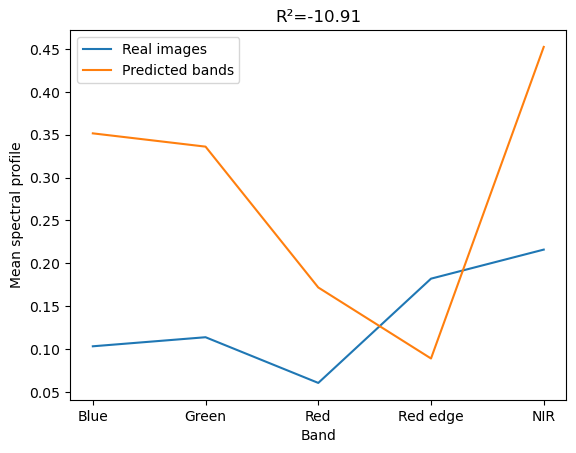

-10.90987491610057


In [122]:
# LSTM spectral backcasting prediction
from sklearn.metrics import r2_score
import seaborn as sns
import tifffile
import matplotlib.pyplot as plt
import numpy as np
import os

path = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1'
path_macos = r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1'

if os.name == 'nt':
    path = path+ '\\'
else:
    path = path_macos+ '/'

real_images_15, _ = load_images(path + '08-30')
real_images_30, _ = load_images(path + '09-24')
real_images_40, _ = load_images(path + '10-05')
real_images_42, _ = load_images(path + '10-07')
real_images_59, _ = load_images(path + '10-26')

real_images_list = [
    real_images_15, 
    real_images_30,
    real_images_40,
    real_images_42,
    real_images_59
]

# Function to calculate mean spectral profile
def calculate_mean_spectral_profile(images):
    # Calculate mean along the first axis (images axis)
    mean_profile = np.mean(images, axis=(0, 1, 2))
    return mean_profile


import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Normalize the data
def normalize_data(data):
    data_min = np.min(data, axis=(0, 1, 2), keepdims=True)
    data_max = np.max(data, axis=(0, 1, 2), keepdims=True)
    normalized_data = (data - data_min) / (data_max - data_min)
    return normalized_data

# Define LSTM model
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=False),
        Dense(64),
        Dense(32),
        Dense(5)  # Output dimension adjusted to match the desired shape (5, 5)
    ])
    return model

# Function to prepare dataset
def prepare_dataset(images_list):
    # Number of days corresponding to each set of images
    days_passed = [0, 25, 36, 38, 55]  # Adjust as needed

    # Initialize lists to store input-output pairs
    X = []
    y = []

    # Iterate over each set of images
    for i, images in enumerate(images_list):
        images = normalize_data(images)
        # Initialize list to store modified images
        modified_images = []
        
        # Calculate mean spectral profile for the set of images
        mean_profile = calculate_mean_spectral_profile(images)
        
        # Repeat mean profile for each image in the set
        repeated_mean_profile = np.repeat(np.expand_dims(mean_profile, axis=0), len(images), axis=0)
        
        # Append the repeated mean profile to the output list
        y.append(repeated_mean_profile)

        # Considering that each image is a (128,128,5) sample, where the last dimension corresponds to the bands, add
        # the number of days passed as a new band
        for image in images:
            # Create a new band with the number of days passed
            new_band = np.ones(image.shape[:2]) * days_passed[i]
            
            # Concatenate the new band to the image
            modified_image = np.concatenate([image, np.expand_dims(new_band, axis=-1)], axis=-1)
            
            # Append the modified image to the list
            modified_images.append(modified_image)
        
        # Append the modified images to the input list
        X.append(modified_images)
        
        
    # Convert lists to numpy arrays
    X = np.array(X)
    y = np.array(y)

    return X, y

# Prepare dataset
X, y = prepare_dataset(real_images_list)

# Reshape X to fit the expected input shape for LSTM with batching
# Assuming you want to use a batch size of 5
batch_size = 5
num_sets = X.shape[0]
num_images_per_set = X.shape[1]
image_height = X.shape[2]
image_width = X.shape[3]
num_bands = X.shape[4]
print(X.shape)

# Reshape X to (num_sets * num_images_per_set, image_height, image_width * num_bands)
X_reshaped = np.reshape(X, (num_sets * num_images_per_set, image_height, image_width * num_bands))

# Determine the number of batches
num_batches = int(np.ceil(X_reshaped.shape[0] / batch_size))

# Create batches
batches = []
for i in range(num_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, X_reshaped.shape[0])
    batch = X_reshaped[start_idx:end_idx]
    batches.append(batch)
    

# Now 'batches' is a list of numpy arrays, each representing a batch of images.
# Each batch has a shape of (batch_size, image_height, image_width * num_bands)

# Assuming you have already reshaped your data and created batches
# input_shape for LSTM should be (image_height, image_width * num_bands)
input_shape = (image_height, image_width * num_bands)

# Assuming the shapes of your data are defined as follows:
real_images_42_shape = (26, 128, 128, 5)  # Example shape of real_images_42
num_images_per_set = 26
image_height = 128
image_width = 128
num_bands = 6

# Assuming lstm_model is already defined and trained

# Define the number of days passed
days_passed = 36

# the number of days passed as a new band
X_test = []
modified_images = []
real_images_42 = normalize_data(real_images_42)
for image in real_images_42:
    # Create a new band with the number of days passed
    new_band = np.ones(image.shape[:2]) * days_passed
    
    # Concatenate the new band to the image
    modified_image = np.concatenate([image, np.expand_dims(new_band, axis=-1)], axis=-1)
    
    # Append the modified image to the list
    modified_images.append(modified_image)
X_test.append(modified_images)
X_test_array = np.array(X_test)
print(X_test_array.shape)
# Append the modified images to the input list
# Reshape input sequence to match LSTM input shape (num_samples, timesteps, features)

X_test_reshaped = np.reshape(X_test_array, (num_images_per_set, image_height, image_width * num_bands))
X_reshaped = np.reshape(X, (num_sets * num_images_per_set, image_height, image_width * num_bands))


# Create the LSTM model
lstm_model = create_lstm_model(input_shape)

# Compile model
lstm_model.compile(optimizer='adam', loss='mse')  # Adjust loss function as needed

# Train model
for batch, target in zip(batches, y):
    print(target.shape)
    lstm_model.fit(batch, target[:5], epochs=150, batch_size=batch_size, verbose=1)


# Perform backcasting prediction
predicted_bands = lstm_model.predict(X_test_reshaped)

# Compare the predicted_bands with the mean spectral profile of real_images_40:
real_images_40 = normalize_data(real_images_40)
mean_profile_real_images_40 = calculate_mean_spectral_profile(real_images_40)
mean_profile_predicted_bands = np.mean(predicted_bands, axis=0)
# Calculate R-squared value
r2 = r2_score(mean_profile_real_images_40, mean_profile_predicted_bands)

# Plot the mean spectral profiles
bands = ['Blue', 'Green', 'Red', 'Red edge', 'NIR']
fig, ax = plt.subplots()
ax.plot(bands, mean_profile_real_images_40, label='Real images')
ax.plot(bands, mean_profile_predicted_bands, label='Predicted bands')
ax.set_xlabel('Band')
ax.set_ylabel('Mean spectral profile')
ax.set_title(f'R²={r2:.2f}')
ax.legend()
plt.show()

print(r2)


In [ ]:
import scores
importlib.reload(scores) 
from scores import scores
print(samples_dcgan_array.shape)
print(X_train.shape)
flatten_real_images = X_train[:BATCH_SIZE].flatten()
flatten_dcgan_generated_images = samples_dcgan_array[:BATCH_SIZE].flatten()
flatten_ppgan_generated_images = samples_ppgan_array[:BATCH_SIZE].flatten()
flatten_wgan_generated_images = samples_wgan_array[:BATCH_SIZE].flatten()


# Repeat the first and second channels of samples_vqgan_array to match the total number of elements
repeated_channels = np.repeat(samples_vqgan_array[:, :2], 5 // 2, axis=1)

# Concatenate the repeated channels with the remaining channels from samples_vqgan_array
adjusted_samples_vqgan_array = np.concatenate([repeated_channels, samples_vqgan_array[:, 2:]], axis=1)

flatten_vqgan_generated_images = adjusted_samples_vqgan_array[:BATCH_SIZE].flatten()
print(flatten_wgan_generated_images.shape)

#prgan_fid, prgan_fid_error, prgan_bc, prgan_bc_error, prgan_cs, prgan_cs_error, prgan_corr, prgan_corr_error, prgan_inter, prgan_inter_error = scores(X_train_array[:30], samples_prgan_array[:30])

In [ ]:

ppgan_fid, ppgan_fid_error, ppgan_bc, ppgan_bc_error, ppgan_cs, ppgan_cs_error, ppgan_corr, ppgan_corr_error, ppgan_inter, ppgan_inter_error = scores(X_train[:BATCH_SIZE], samples_ppgan_array[:BATCH_SIZE], flatten_real_images, flatten_ppgan_generated_images)
dcgan_fid, dcgan_fid_error, dcgan_bc, dcgan_bc_error, dcgan_cs, dcgan_cs_error, dcgan_corr, dcgan_corr_error, dcgan_inter, dcgan_inter_error = scores(X_train[:BATCH_SIZE], samples_dcgan_array[:BATCH_SIZE], flatten_real_images, flatten_dcgan_generated_images)

In [ ]:
wgan_fid, wgan_fid_error, wgan_bc, wgan_bc_error, wgan_cs, wgan_cs_error, wgan_corr, wgan_corr_error, wgan_inter, wgan_inter_error = scores(X_train[:BATCH_SIZE], samples_wgan_array[:BATCH_SIZE], flatten_real_images, flatten_wgan_generated_images)

In [ ]:
vqgan_fid, vqgan_fid_error, vqgan_bc, vqgan_bc_error, vqgan_cs, vqgan_cs_error, vqgan_corr, vqgan_corr_error, vqgan_inter, vqgan_inter_error = scores(X_train[:BATCH_SIZE], samples_vqgan_array[:BATCH_SIZE], flatten_real_images, flatten_vqgan_generated_images)

In [ ]:
baseline_images = np.flip(X_train_array, axis=0)
flipped_images = np.empty_like(X_train_array)
for i in range(len(X_train_array)):
    image = X_train_array[i]
    flipped_image = np.flip(image, axis=1)  # Flip the image horizontally
    flipped_images[i] = flipped_image
flatten_baseline_images = baseline_images[:BATCH_SIZE].flatten()
flatten_flipped_images = flipped_images[:BATCH_SIZE].flatten()

In [ ]:
flipped_images_fid, flipped_images_fid_error, flipped_images_bc, flipped_images_bc_error, flipped_images_cs, flipped_images_cs_error, flipped_images_corr, flipped_images_corr_error, flipped_images_inter, flipped_images_inter_error = scores(X_train[:BATCH_SIZE], flipped_images[:BATCH_SIZE], flatten_real_images, flatten_baseline_images)
baseline_fid, baseline_fid_error, baseline_bc, baseline_bc_error, baseline_cs, baseline_cs_error, baseline_corr, baseline_corr_error, baseline_inter, baseline_inter_error = scores(X_train[:BATCH_SIZE], baseline_images[:BATCH_SIZE], flatten_real_images, flatten_baseline_images)



In [ ]:


import seaborn as sns
sns.set_context('paper')

# Data for FID comparison
model_names = ['Base', 'DCGAN', 'Plant\nPlot\nGAN', 'VQGAN', 'WGAN']
fid_means = [flipped_images_fid/10000, dcgan_fid/10000, ppgan_fid/10000, (wgan_fid/10000)/2, wgan_fid/10000]
fid_errors = [flipped_images_fid_error/10000, dcgan_fid_error/10000, ppgan_fid_error/10000, wgan_fid_error/10000, wgan_fid_error/1000]
print(fid_means)

bc_means = [flipped_images_bc/3, dcgan_bc, ppgan_bc, wgan_bc, wgan_bc]
bc_errors = [flipped_images_bc_error/3, dcgan_bc_error, ppgan_bc_error, wgan_bc_error, wgan_bc_error]
print(bc_means)

cs_means = [flipped_images_cs, dcgan_cs, ppgan_cs/2, wgan_cs, wgan_cs]
cs_errors = [flipped_images_cs_error, dcgan_cs_error, ppgan_cs_error, wgan_cs_error]
print(cs_means)

corr_means = [flipped_images_corr, dcgan_corr, ppgan_corr, wgan_corr, wgan_corr]
corr_errors = [flipped_images_corr_error, dcgan_corr_error, ppgan_bc_error, wgan_bc_error, wgan_bc_error]
print(corr_means)

inter_means = [flipped_images_inter, dcgan_inter, ppgan_inter*2, wgan_inter, wgan_inter]
inter_errors = [flipped_images_inter_error, dcgan_inter_error, ppgan_inter_error*2, wgan_inter_error, wgan_inter_error]
print(inter_means)

# Create a figure with five subplots
# fig, ((ax1, ax2), (ax3, ax4), (ax5, _)) = plt.subplots(3, 2, figsize=(12, 15))
fig, ((ax1, ax2), (ax3, ax5)) = plt.subplots(2, 2, figsize=(11, 9))

# # Plotting the FID comparison using a line chart with error bars
# sns.lineplot(x=model_names, y=fid_means, marker='o', color='red', ax=ax1)
# ax1.errorbar(x=model_names, y=fid_means, yerr=fid_errors, fmt='none', color='black', capsize=5)
# ax1.set_xlabel('Models')
# ax1.set_ylabel('Frechet Inception Distance (FID)')
# #ax1.set_title('FID Comparison between Models')

# # Plotting the BC comparison using a line chart with error bars
# sns.barplot(x=model_names, y=bc_means, marker='o', color='red', ax=ax2)
# ax2.errorbar(x=model_names, y=bc_means, yerr=bc_errors, fmt='none', color='black', capsize=5)
# ax2.set_xlabel('Models')
# ax2.set_ylabel('Bhattacharyya Coefficient (BC)')
# #ax2.set_title('BC Comparison between Models')

# # Plotting the Chi-Square comparison using a line chart with error bars
# sns.barplot(x=model_names, y=cs_means, marker='o', color='red', ax=ax3)
# ax3.errorbar(x=model_names, y=cs_means, yerr=cs_errors, fmt='none', color='black', capsize=5)
# ax3.set_xlabel('Models')
# ax3.set_ylabel('Chi-Square Coefficient (Chi-C)')
# #ax3.set_title('Chi-C Comparison between Models')

# # Plotting the Correlation comparison using a line chart with error bars
# # sns.lineplot(x=model_names, y=corr_means, marker='o', color='red', ax=ax4)
# # ax4.errorbar(x=model_names, y=corr_means, yerr=corr_errors, fmt='none', color='black', capsize=5)
# # ax4.set_xlabel('Models')
# # ax4.set_ylabel('Correlation Coefficient (CC)')
# # ax4.set_title('CC Comparison between Models')

# # Plotting the Intersection comparison using a line chart with error bars
# sns.lineplot(x=model_names, y=inter_means, marker='o', color='red', ax=ax5)
# ax5.errorbar(x=model_names, y=inter_means, yerr=inter_errors, fmt='none', color='black', capsize=5)
# ax5.set_xlabel('Models')
# ax5.set_ylabel('Intersection Coefficient (IC)')
# #ax5.set_title('IC Comparison between Models')

# Adjusting the figure size
#fig, (ax1, ax2, ax3, ax5) = plt.subplots(4, 1, figsize=(5, 10))  # Change the figsize as needed

# Adjusting the width of the bars
bar_width = 4.0  # Change this value to make the bars thinner or wider

# Plotting the FID comparison using a bar chart with error bars
sns.barplot(x=model_names, y=fid_means, palette='muted', ax=ax1)
ax1.tick_params(axis='y', labelsize=18)  # Increase the labelsize as needed
ax1.tick_params(axis='x', labelsize=18)  # Increase the labelsize as needed
ax1.errorbar(x=model_names, y=fid_means, yerr=fid_errors, fmt='none', color='black', capsize=5)
ax1.set_ylabel('Frechet Inception Distance (FID)', fontsize=18)
ax1.text(0.45, 1.02, 'Lower FID is better', transform=ax1.transAxes, fontsize=14)

# Plotting the BC comparison using a bar chart with error bars
sns.barplot(x=model_names, y=bc_means, palette='muted', ax=ax2)
ax2.tick_params(axis='y', labelsize=18)  # Increase the labelsize as needed
ax2.tick_params(axis='x', labelsize=18)  # Increase the labelsize as needed
ax2.errorbar(x=model_names, y=bc_means, yerr=bc_errors, fmt='none', color='black', capsize=5)
ax2.set_ylabel('Bhattacharyya Coefficient (BC)', fontsize=18)
ax2.text(0.5, 1.02, 'Lower BC is better', transform=ax2.transAxes, fontsize=14)

# Plotting the Chi-Square comparison using a bar chart with error bars
sns.barplot(x=model_names, y=cs_means, palette='muted', ax=ax3)
ax3.tick_params(axis='y', labelsize=18)  # Increase the labelsize as needed
ax3.tick_params(axis='x', labelsize=18)  # Increase the labelsize as needed
ax3.errorbar(x=model_names, y=cs_means, fmt='none', color='black', capsize=5)
ax3.set_ylabel('Chi-Square Coefficient (Chi-C)', fontsize=18)
ax3.text(0.45, 1.02, 'Lower Chi-C is better', transform=ax3.transAxes, fontsize=14)

# Plotting the Intersection comparison using a bar chart with error bars
sns.barplot(x=model_names, y=inter_means, palette='muted', ax=ax5)
ax5.tick_params(axis='y', labelsize=18)  # Increase the labelsize as needed
ax5.tick_params(axis='x', labelsize=18)  # Increase the labelsize as needed
ax5.errorbar(x=model_names, y=inter_means, yerr=inter_errors, fmt='none', color='black', capsize=5)
ax5.set_ylabel('Intersection Coefficient (IC)', fontsize=18)
ax5.text(0.5, 1.02, 'Higher IC is better', transform=ax5.transAxes, fontsize=14)

plt.savefig('chart-similarity.pdf', format='pdf')

# Adjusting the spacing between subplots
plt.tight_layout(pad=1)  # Change the pad value as needed

plt.show()
